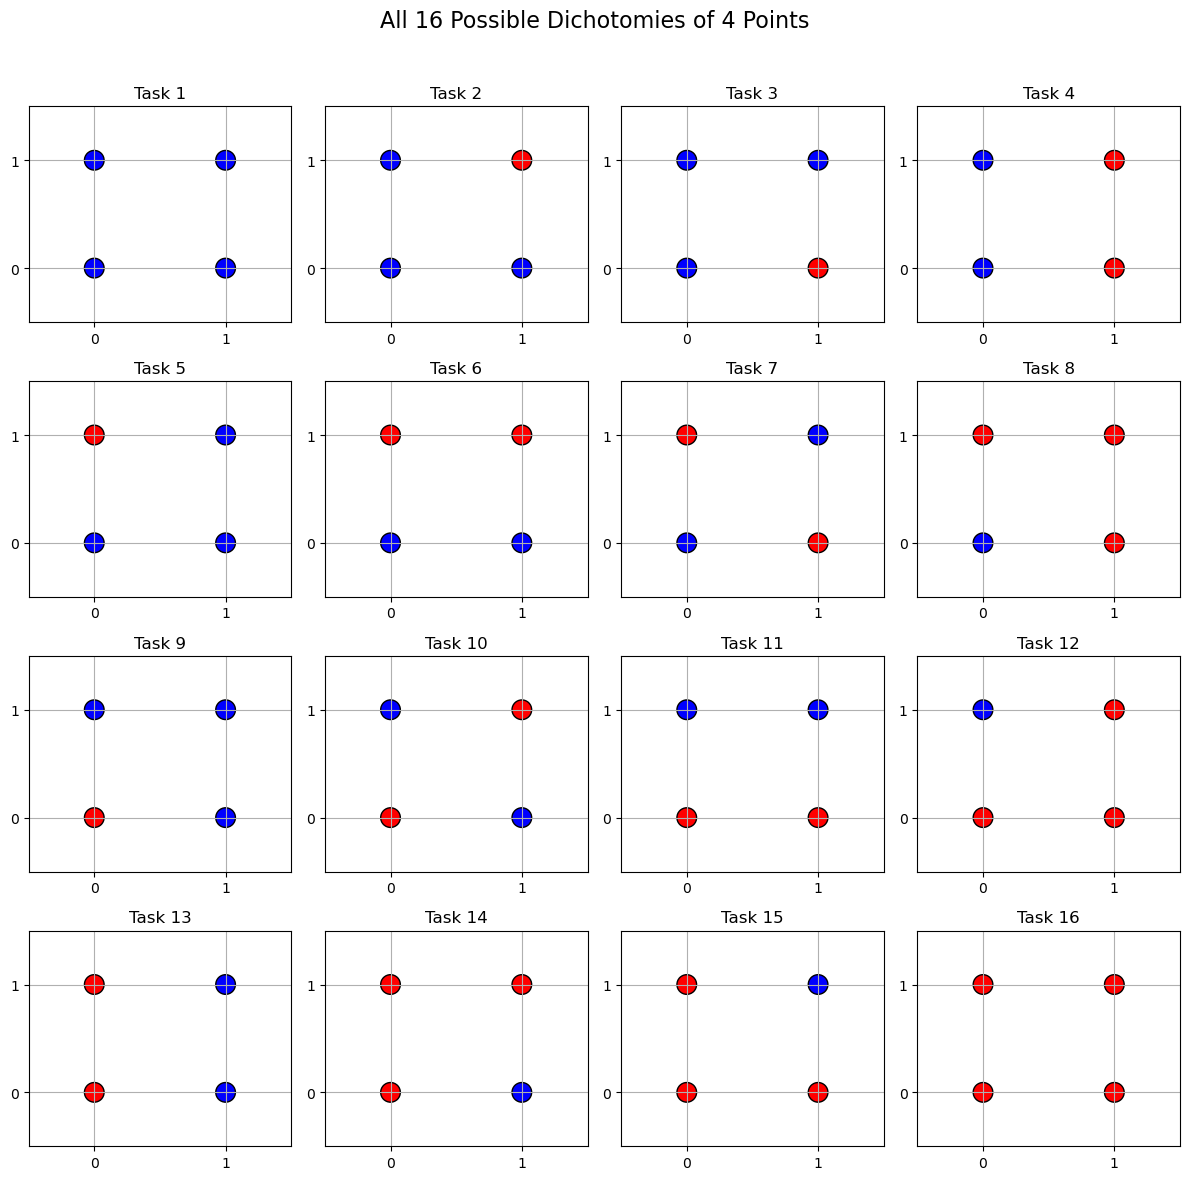

In [1]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

def plot_classification(labels, ax, index):
    points = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    colors = ['red' if label == 1 else 'blue' for label in labels]
    
    ax.scatter(points[:, 0], points[:, 1], c=colors, s=200, edgecolors='black')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(f"Task {index}")
    ax.grid(True)

# Generate all possible binary classifications of 4 points
all_labelings = list(itertools.product([-1, 1], repeat=4))

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle("All 16 Possible Dichotomies of 4 Points", fontsize=16)

for i, (labels, ax) in enumerate(zip(all_labelings, axes.flatten())):
    plot_classification(labels, ax, i+1)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models,initializers
import numpy as np
import time

tf.disable_eager_execution()

# Custom Bias-Only Layer
class BiasOnlyLayer(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, initializer='zeros', **kwargs):
        super(BiasOnlyLayer, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)
        self.initializer = initializer
    
    def build(self, input_shape):
        # Create only bias, no weights
        self.bias = self.add_weight(
            name='bias', 
            shape=(self.units,),
            initializer=self.initializer,
            trainable=True
        )
        super(BiasOnlyLayer, self).build(input_shape)
    
    def call(self, inputs):
        # Just add bias
        output = inputs + self.bias
        
        # Apply activation if specified
        if self.activation is not None:
            output = self.activation(output)
        
        return output

# Hyperparameters
num_epochs = 10
batch_size = 64
n_neurons = 64
learning_rate = 0.02

class CustomUniformInitializer(tf.keras.initializers.Initializer):
    def __call__(self, shape, dtype=None, partition_info=None):
        # Generate uniform samples in [0, 1)
        samples = tf.random.uniform(shape, minval=0, maxval=1, dtype=dtype)
        
        # Map half of them to [-3, -1] and half to [1, 3]
        mapped_samples = tf.where(samples < 0.5,  # Condition
                                  -3 + 2 * samples,  # Scale to [-3, -1]
                                  1 + 2 * (samples - 0.5))  # Scale to [1, 3]
        return mapped_samples

custom_initializer=CustomUniformInitializer()
uniform_initializer=tf.keras.initializers.RandomUniform(minval=-3,maxval=3)

# Create the model
model_template = models.Sequential([
    layers.InputLayer(input_shape=(2,)),
    
    # First layer without bias
    layers.Dense(n_neurons, use_bias=False, trainable=False, kernel_initializer=uniform_initializer),
    
    # Custom bias-only layer for first hidden layer
    BiasOnlyLayer(n_neurons, activation='relu'),
    
    # Output layer without bias
    layers.Dense(1, use_bias=False, trainable=False, kernel_initializer=uniform_initializer), #, kernel_initializer=tf.constant_initializer([1.,1.])
    
    # Custom bias-only layer for output
    BiasOnlyLayer(1, activation='sigmoid')
])

# Compile the model
model_template.compile(
    optimizer=tf.keras.optimizers.Adam(lr=learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_template.summary()

# Print initial variables
#print("Initial Variables:")
#for v in model_template.variables:
#    print(f"{v.name}: {v.numpy()}")

# Generate training data
train_points = np.random.choice([0, 1], size=(10000, 2))  

task_labels={
    'task1' : np.array([0 for point in train_points]), # 0
    'task2' : np.array([(point[0] and point[1]) for point in train_points]),  # x AND y
    'task3' : np.array([(point[0] and not(point[1])) for point in train_points]), # x AND NOT(y)
    'task4' : np.array([point[0] for point in train_points]), # x
    'task5' : np.array([(not(point[0]) and point[1]) for point in train_points]), # NOT(x) AND y
    'task6' : np.array([point[1] for point in train_points]), # y
    'task7' : np.array([point[0]^point[1] for point in train_points]), # x XOR y
    'task8' : np.array([(point[0] or point[1]) for point in train_points]), # x OR y 
    'task9' : np.array([(not(point[0]) and not(point[1])) for point in train_points]), # NOT(x) AND NOT(y)
    'task10' : np.array([not(point[0]^point[1]) for point in train_points]), # NOT(x XOR y)
    'task11' : np.array([not(point[1]) for point in train_points]), # NOT(y)
    'task12' : np.array([(point[0] or not(point[1])) for point in train_points]), # x OR NOT(y)
    'task13' : np.array([not(point[0]) for point in train_points]), # NOT(x)
    'task14' : np.array([(not(point[0]) or point[1]) for point in train_points]), # NOT(x) OR y
    'task15' : np.array([(not(point[0]) or not(point[1])) for point in train_points]), # NOT(x) OR NOT(y)
    'task16' : np.array([1 for point in train_points]), # 1
    }

# Training callback
class StopOnPoint(tf.keras.callbacks.Callback):
    def __init__(self, point):
        super(StopOnPoint, self).__init__()
        self.point = point
    
    def on_epoch_end(self, epoch, logs=None):
        accuracy = logs.get("acc")
        if accuracy and accuracy >= self.point:
            self.model.stop_training = True

# Callbacks
callbacks = [StopOnPoint(1.0)]

last_time=time.time()

parameters={}

def distance_loss(weights):

    w1=weights[0]
    b1=weights[1]
    w2=weights[2]
    b2=weights[3]
    
    points = tf.constant([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=tf.float32)

    hidden = tf.nn.relu(tf.matmul(points, w1) + b1)
    decision_scores = tf.matmul(hidden, w2) + b2
    norm = tf.norm(w2, axis=0) + 1e-8
    distances = tf.abs(decision_scores) / norm

    return tf.reduce_mean(distances)


for task in task_labels: 

    #if task != 'task7_labels':continue

    print(f'Running {task}')

    model_train = models.Sequential([
                                        layers.InputLayer(input_shape=(2,)),
                                        
                                        # First layer without bias
                                        layers.Dense(n_neurons, use_bias=False, trainable=False, kernel_initializer=uniform_initializer),
                                        
                                        # Custom bias-only layer for first hidden layer
                                        BiasOnlyLayer(n_neurons, activation='relu'),
                                        
                                        # Output layer without bias
                                        layers.Dense(1, use_bias=False, trainable=False), #, kernel_initializer=tf.constant_initializer([1.,1.])
                                        
                                        # Custom bias-only layer for output
                                        BiasOnlyLayer(1, activation='sigmoid')
                                        ])

    model_train.compile(
                            optimizer=tf.keras.optimizers.Adam(lr=learning_rate),
                            loss=lambda y_true, y_pred: tf.keras.losses.binary_crossentropy(y_true, y_pred)+distance_loss(model_train.get_weights()),
                            metrics=['accuracy']
                        )
    model_train.set_weights(model_template.get_weights())

    # Print final variables
    #print("\n Variables before training:")
    #for v in model_train.variables:
    #    print(f"{v.name}: {v.numpy()}")

    # Train the model
    train_history = model_train.fit(
        train_points, task_labels[task],
        epochs=100,
        shuffle=True,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    time_now=time.time()
    print(f'Training finished in {(time_now-last_time)} seconds')
    last_time=time_now

    # Print final variables
    #print("\n Variables after training:")
    #for v in model_train.variables:
    #    print(f"{v.name}: {v.numpy()}")

    parameters[task]=model_train.get_weights()

/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:526: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:527: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/fbraidi/miniconda3/envs/thesis-env/lib/python3.7/site-packages/tensorflow/python/framework/dtypes.py:528: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/fbraidi/miniconda3/env

Instructions for updating:
Colocations handled automatically by placer.
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                128       
_________________________________________________________________
bias_only_layer (BiasOnlyLay (None, 64)                64        
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 64        
_________________________________________________________________
bias_only_layer_1 (BiasOnlyL (None, 1)                 1         
Total params: 257
Trainable params: 65
Non-trainable params: 192
_________________________________________________________________
Running task1
Instructions for updating:
Use tf.cast instead.


2025-03-31 13:21:14.117791: I tensorflow/core/platform/cpu_feature_guard.cc:141] Your CPU supports instructions that this TensorFlow binary was not compiled to use: AVX2 AVX512F FMA
2025-03-31 13:21:14.125642: I tensorflow/core/platform/profile_utils/cpu_utils.cc:94] CPU Frequency: 3099855000 Hz
2025-03-31 13:21:14.130415: I tensorflow/compiler/xla/service/service.cc:150] XLA service 0x3686b50 executing computations on platform Host. Devices:
2025-03-31 13:21:14.130433: I tensorflow/compiler/xla/service/service.cc:158]   StreamExecutor device (0): <undefined>, <undefined>


Epoch 1/100
10000/10000 [==============================] - 0s 19us/sample - loss: 0.2877 - acc: 0.9835
Epoch 2/100
10000/10000 [==============================] - 0s 16us/sample - loss: 0.2381 - acc: 1.0000
Training finished in 0.6182358264923096 seconds
Running task2
Epoch 1/100
10000/10000 [==============================] - 0s 19us/sample - loss: 1.6993 - acc: 0.8457
Epoch 2/100
10000/10000 [==============================] - 0s 16us/sample - loss: 1.1247 - acc: 1.0000
Training finished in 0.7000529766082764 seconds
Running task3
Epoch 1/100
10000/10000 [==============================] - 0s 19us/sample - loss: 1.8223 - acc: 0.9916
Epoch 2/100
10000/10000 [==============================] - 0s 16us/sample - loss: 1.7825 - acc: 1.0000
Training finished in 0.700791597366333 seconds
Running task4
Epoch 1/100
10000/10000 [==============================] - 0s 18us/sample - loss: 1.4491 - acc: 0.7850
Epoch 2/100
10000/10000 [==============================] - 0s 16us/sample - loss: 0.8568 - acc

Calculating predictions of points for each task


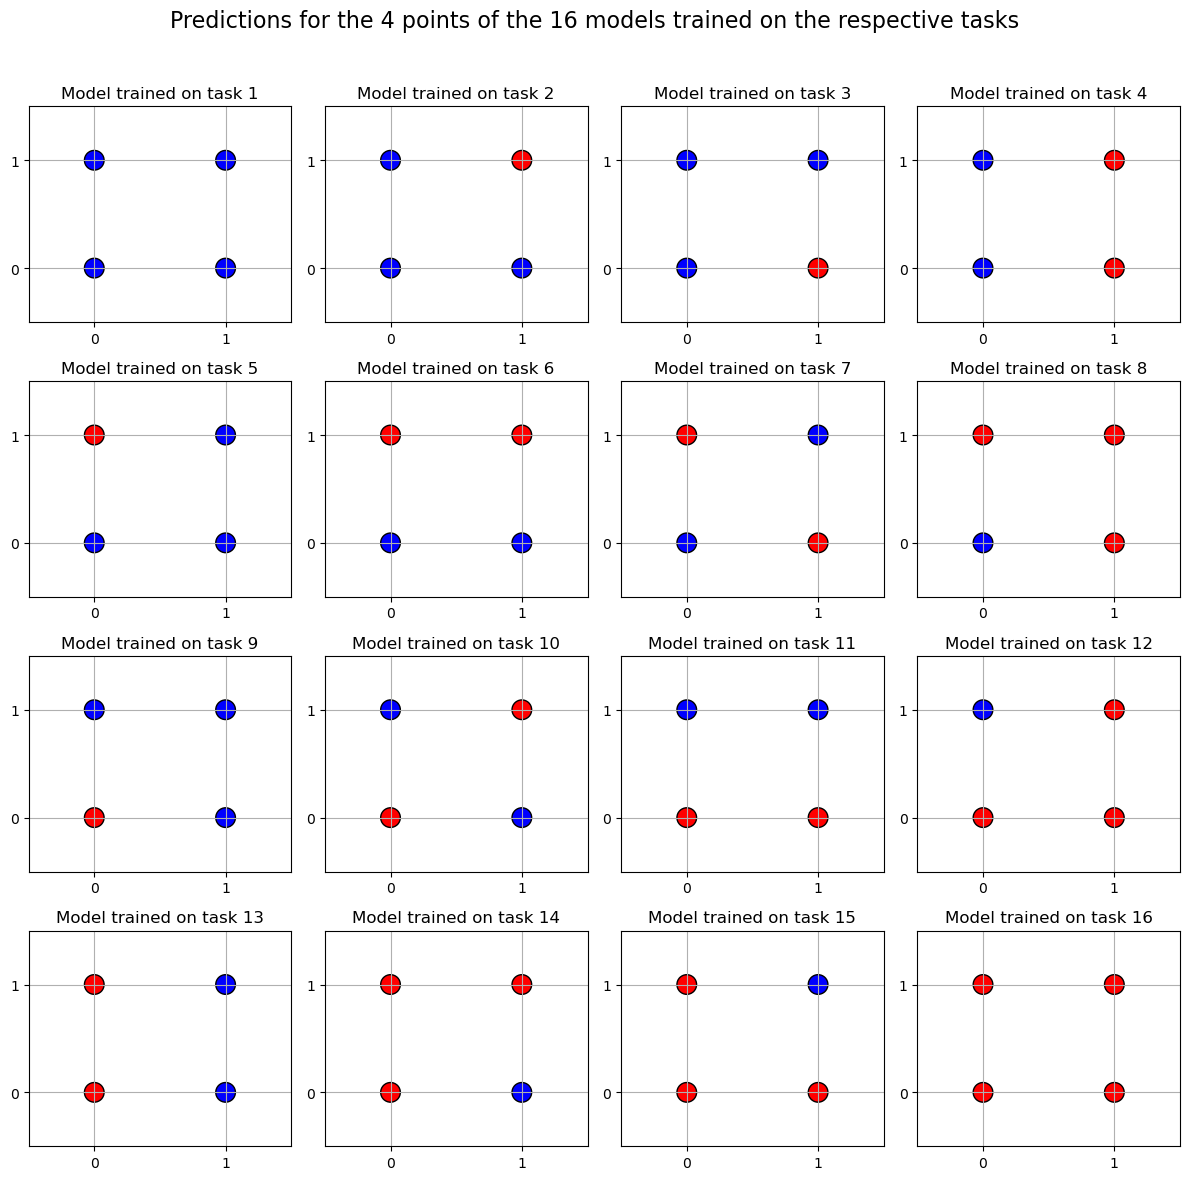

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def plot_classification(labels, ax, index):
    points = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    colors = ['red' if label == 1 else 'blue' for label in labels]
    
    ax.scatter(points[:, 0], points[:, 1], c=colors, s=200, edgecolors='black')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(f"Model trained on task {index}")
    ax.grid(True)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle("Predictions for the 4 points of the 16 models trained on the respective tasks", fontsize=16)

print(f'Calculating predictions of points for each task')

for i, (task,ax) in (enumerate(zip(list(parameters.keys()),axes.flatten()))): 

    model_test = models.Sequential([
                                        layers.InputLayer(input_shape=(2,)),
                                        
                                        # First layer without bias
                                        layers.Dense(n_neurons, use_bias=False, trainable=False, kernel_initializer=uniform_initializer),
                                        
                                        # Custom bias-only layer for first hidden layer
                                        BiasOnlyLayer(n_neurons, activation='relu'),
                                        
                                        # Output layer without bias
                                        layers.Dense(1, use_bias=False, trainable=False, kernel_initializer=uniform_initializer), #, kernel_initializer=tf.constant_initializer([1.,1.])
                                        
                                        # Custom bias-only layer for output
                                        BiasOnlyLayer(1, activation='sigmoid')
                                        ])

    model_test.compile(
                            optimizer=tf.keras.optimizers.Adam(lr=learning_rate),
                            loss='binary_crossentropy',
                            metrics=['accuracy']
                        )
    model_test.set_weights(parameters[task])

    # Print final variables
    #print("\n Variables before training:")
    #for v in model_train.variables:
    #    print(f"{v.name}: {v.numpy()}")

    labels=[model_test.predict(np.array([[0, 0]])),
            model_test.predict(np.array([[0, 1]])),
            model_test.predict(np.array([[1, 0]])),
            model_test.predict(np.array([[1, 1]]))]
    
    labels=[1 if label > 0.5 else 0 for label in labels]

    plot_classification(labels, ax, i+1)

    # Print final variables
    #print("\n Variables after training:")
    #for v in model_train.variables:
    #    print(f"{v.name}: {v.numpy()}")

    #parameters[task]=model_train.get_weights()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [3]:
firsttask='task2'
secondtask='task8'

for a_in in np.linspace(0,1,11):

    a=int(a_in*10)/10
    b=int((1-a)*10)/10

    print(f'Predictions for model with biases mixed between {firsttask} {a} and {secondtask} {b}')

    w_1=parameters[firsttask][0]
    b_1=a*parameters[firsttask][1]+b*parameters[secondtask][1]
    w_2=parameters[firsttask][2]
    b_2=a*parameters[firsttask][3]+b*parameters[secondtask][3]

    model_test = models.Sequential([
                                    layers.InputLayer(input_shape=(2,)),
                                    
                                    # First layer without bias
                                    layers.Dense(n_neurons, use_bias=False, trainable=False, kernel_initializer=tf.constant_initializer(w_1)),
                                    
                                    # Custom bias-only layer for first hidden layer
                                    BiasOnlyLayer(n_neurons, activation='relu', initializer=tf.constant_initializer(b_1)),
                                    
                                    # Output layer without bias
                                    layers.Dense(1, use_bias=False, trainable=False, kernel_initializer=tf.constant_initializer(w_2)), #, kernel_initializer=tf.constant_initializer([1.,1.])
                                    
                                    # Custom bias-only layer for output
                                    BiasOnlyLayer(1, activation='sigmoid', initializer=tf.constant_initializer(b_2))
                                    ])

    print(model_test.predict(np.array([[0, 0]])),
    model_test.predict(np.array([[0, 1]])),
    model_test.predict(np.array([[1, 0]])),
    model_test.predict(np.array([[1, 1]])))

Predictions for model with biases mixed between task2 0.0 and task8 1.0


[[0.05640158]] [[0.9999999]] [[0.9999896]] [[0.9963815]]
Predictions for model with biases mixed between task2 0.1 and task8 0.9
[[0.13948105]] [[0.9999993]] [[0.9999602]] [[0.99600357]]
Predictions for model with biases mixed between task2 0.2 and task8 0.8
[[0.24502991]] [[0.9999958]] [[0.99979]] [[0.9954972]]
Predictions for model with biases mixed between task2 0.3 and task8 0.7
[[0.36877587]] [[0.9999713]] [[0.99889463]] [[0.9944905]]
Predictions for model with biases mixed between task2 0.4 and task8 0.6
[[0.49456105]] [[0.9997776]] [[0.9936079]] [[0.9932602]]
Predictions for model with biases mixed between task2 0.5 and task8 0.5
[[0.6028896]] [[0.99825484]] [[0.96345896]] [[0.9917576]]
Predictions for model with biases mixed between task2 0.6 and task8 0.4
[[0.53380007]] [[0.98644376]] [[0.8172635]] [[0.9899234]]
Predictions for model with biases mixed between task2 0.7 and task8 0.3
[[0.27174422]] [[0.90250236]] [[0.43137053]] [[0.9874401]]
Predictions for model with biases mi

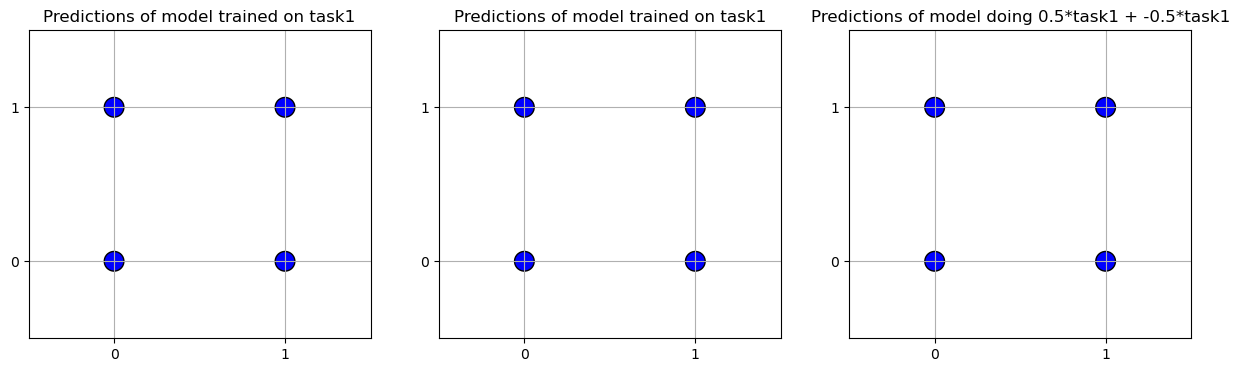

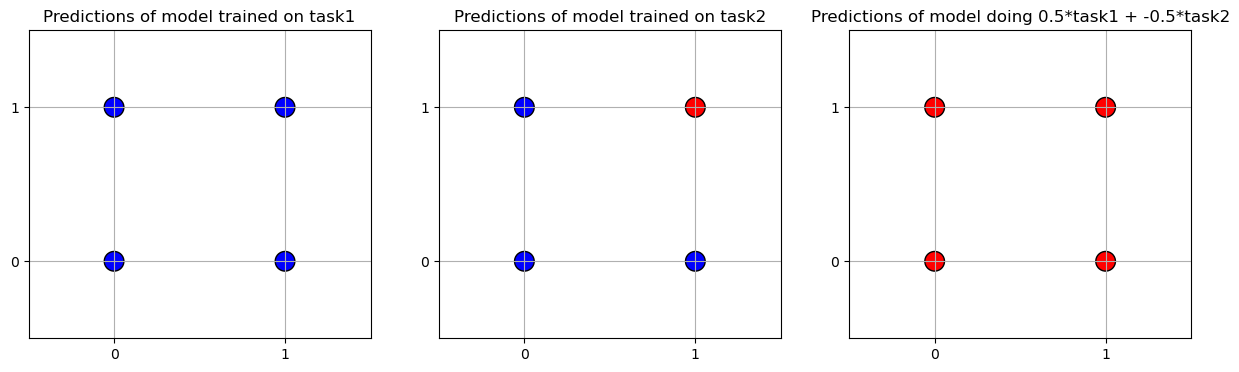

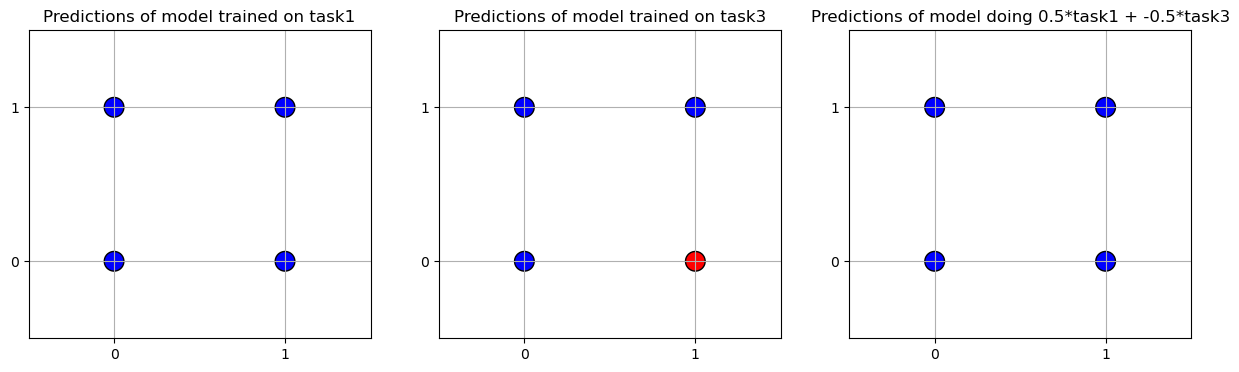

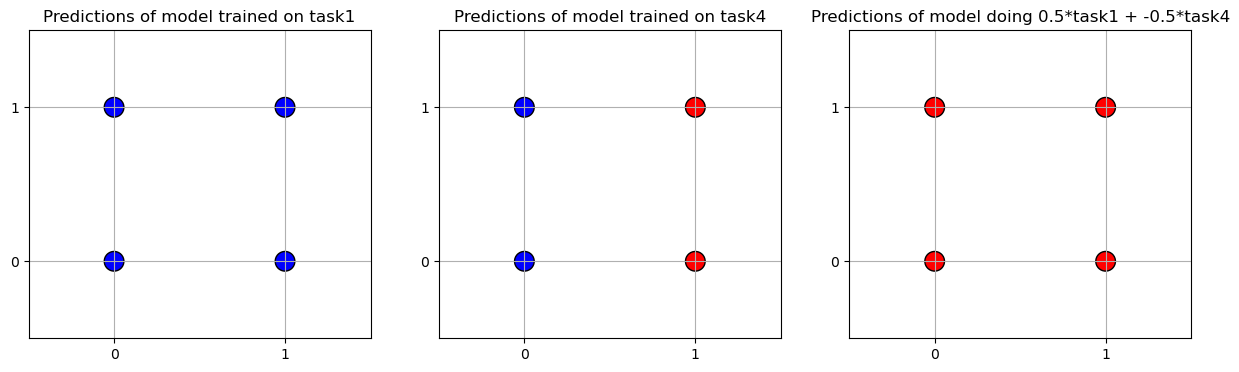

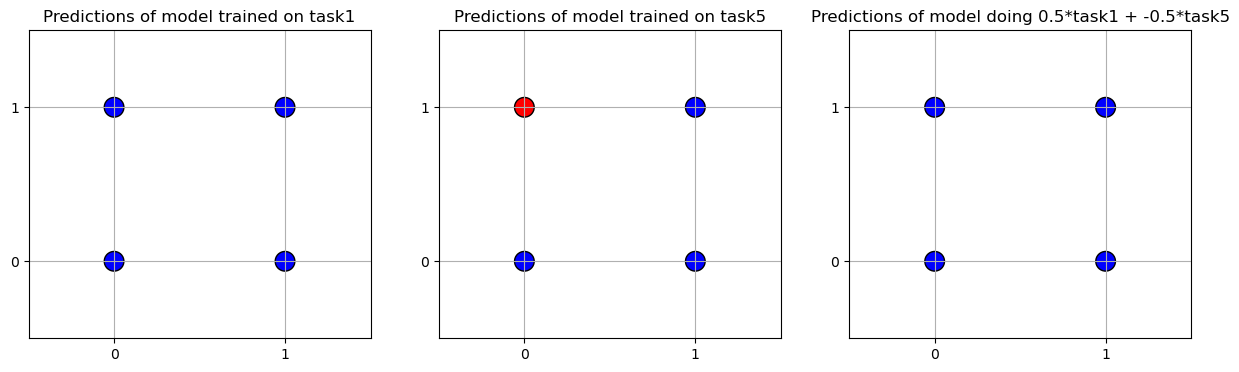

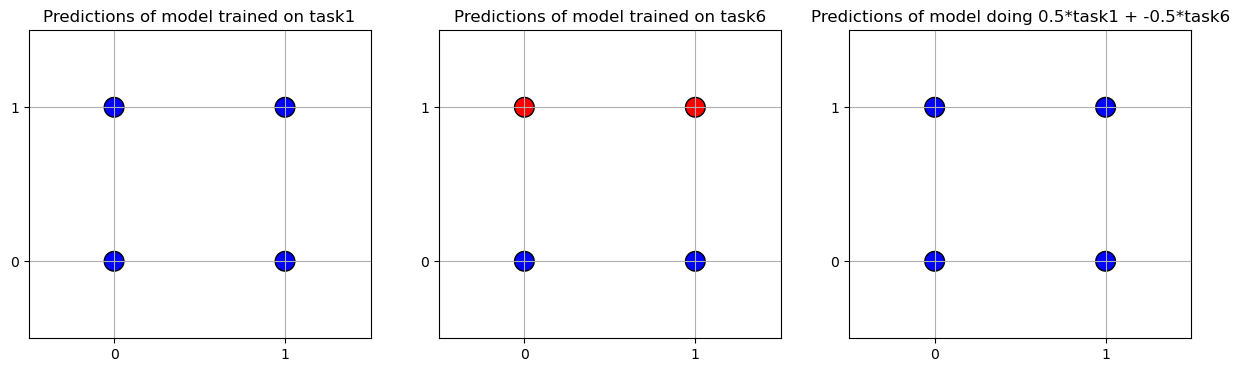

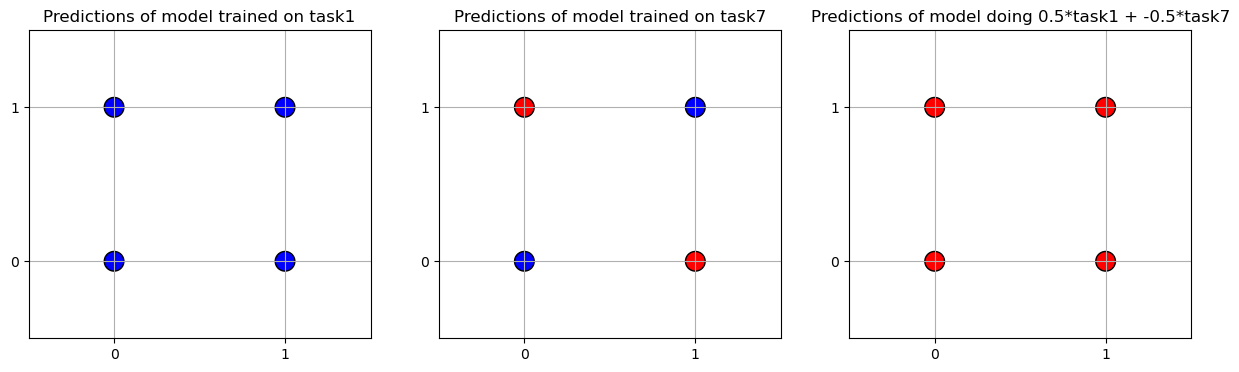

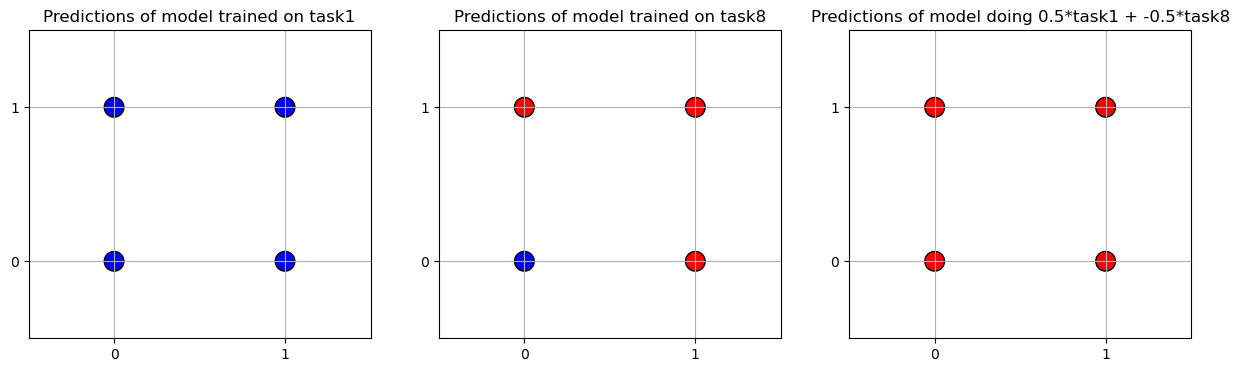

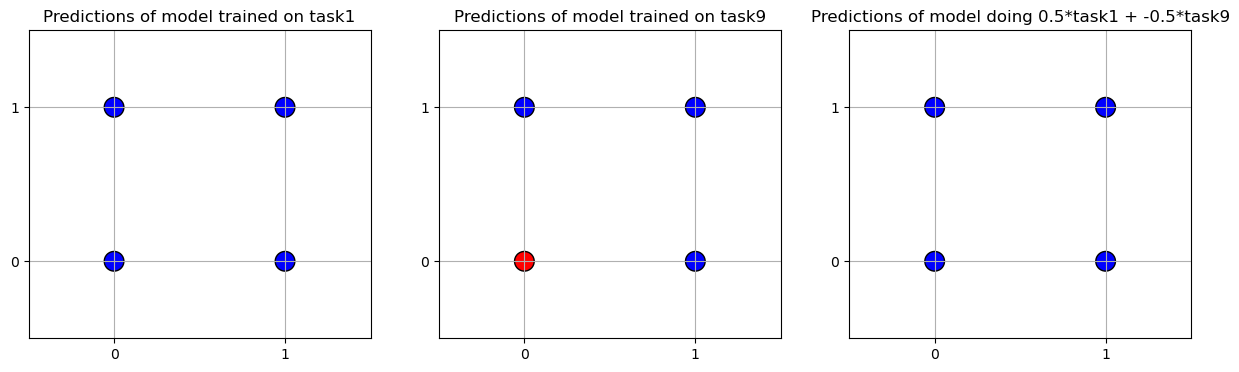

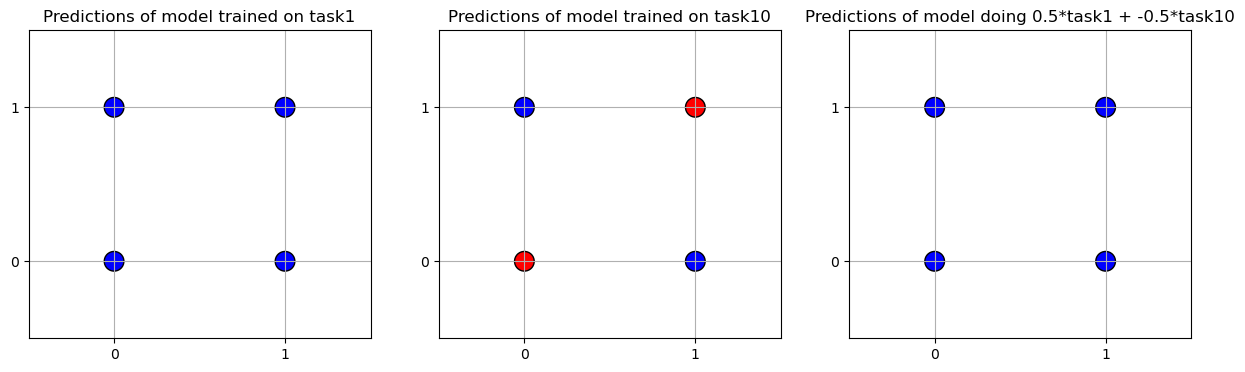

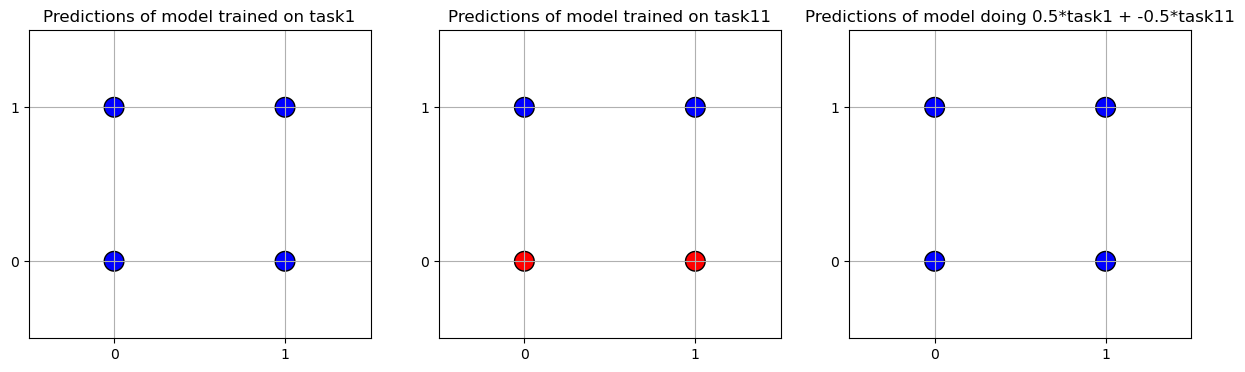

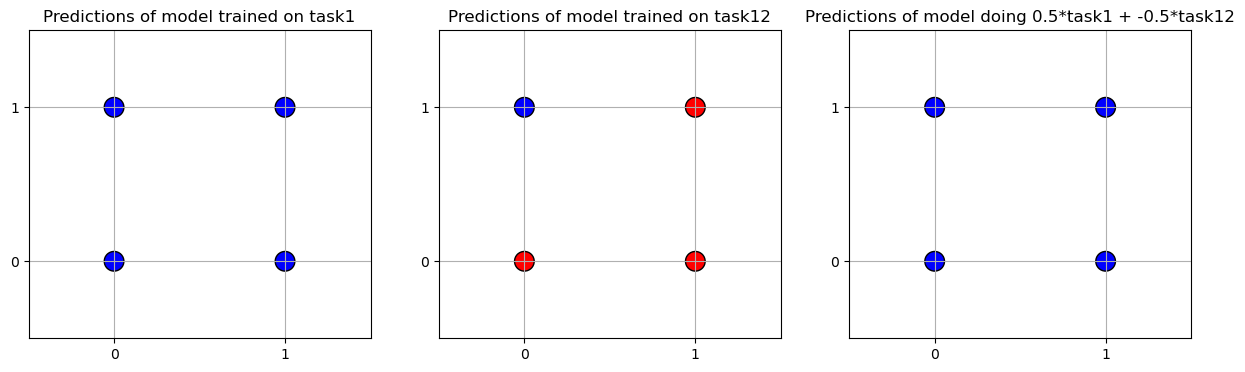

KeyboardInterrupt: 

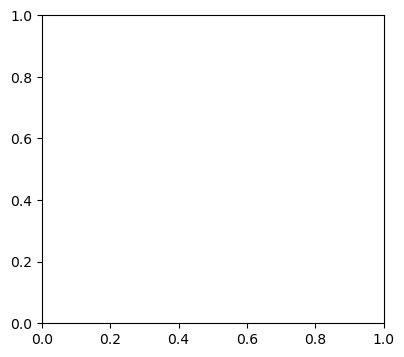

In [5]:
def plot_classification(labels, ax, index, title):
    points = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    colors = ['red' if label == 1 else 'blue' for label in labels]
    
    ax.scatter(points[:, 0], points[:, 1], c=colors, s=200, edgecolors='black')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(f"{title}")
    ax.grid(True)

a=0.5
b=-0.5

for task1 in parameters.keys():
    for task2 in parameters.keys():

        w_1_comp=a*parameters[task1][0]+b*parameters[task2][0]
        b_1_comp=a*parameters[task1][1]+b*parameters[task2][1]
        w_2_comp=a*parameters[task1][2]+b*parameters[task2][2]
        b_2_comp=a*parameters[task1][3]+b*parameters[task2][3]

        run_params=[parameters[task1],parameters[task2],[w_1_comp,b_1_comp,w_2_comp,b_2_comp]]
        titles=[f'Predictions of model trained on {task1}',f'Predictions of model trained on {task2}',f'Predictions of model doing {a}*{task1} + {b}*{task2}']

        model_test = models.Sequential([
                                        layers.InputLayer(input_shape=(2,)),
                                        
                                        # First layer without bias
                                        layers.Dense(n_neurons, use_bias=False, trainable=False, kernel_initializer=tf.constant_initializer(w_1)),
                                        
                                        # Custom bias-only layer for first hidden layer
                                        BiasOnlyLayer(n_neurons, activation='relu', initializer=tf.constant_initializer(b_1)),
                                        
                                        # Output layer without bias
                                        layers.Dense(1, use_bias=False, trainable=False, kernel_initializer=tf.constant_initializer(w_2)), #, kernel_initializer=tf.constant_initializer([1.,1.])
                                        
                                        # Custom bias-only layer for output
                                        BiasOnlyLayer(1, activation='sigmoid', initializer=tf.constant_initializer(b_2))
                                        ])

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        for i,(params,ax,title) in enumerate(zip(run_params,axes,titles)):

            model_test.set_weights(params)

            labels=[model_test.predict(np.array([[0, 0]])),
                model_test.predict(np.array([[0, 1]])),
                model_test.predict(np.array([[1, 0]])),
                model_test.predict(np.array([[1, 1]]))]
        
            labels=[1 if label > 0.5 else 0 for label in labels]

            plot_classification(labels, ax, i+1, f'{title}')
        plt.show()

In [ ]:
import networkx as nx

def visualize_nn_vertical(model):
    """ Generates a vertical graph of the neural network with weights and biases. """
    G = nx.DiGraph()
    
    # Extract the weights from your model
    weights = model.get_weights()
    
    # For your specific model structure with BiasOnlyLayers
    w1 = weights[0]  # First layer weights
    b1 = weights[1]  # First layer biases
    w2 = weights[2]  # Second layer weights
    b2 = weights[3]  # Second layer biases
    
    # Define layer sizes
    input_size = w1.shape[0]
    hidden_size = w1.shape[1]
    output_size = w2.shape[1]
    
    # Create positions dictionary and graph nodes
    pos = {}
    
    # Input layer (bottom)
    input_nodes = []
    for i in range(input_size):
        node_id = f'in_{i+1}'
        G.add_node(node_id, layer=0)
        # Swap x and y coordinates for vertical layout
        pos[node_id] = (i*20-10, 0)
        input_nodes.append(node_id)
    
    # Hidden layer (middle)
    hidden_nodes = []
    for i in range(hidden_size):
        node_id = f'h_{i}:\nw1:{w1[0, i]:.2f}\nw2:{w1[1, i]:.2f}\nb:{b1[i]:.2f}'
        G.add_node(node_id, layer=1)
        # Swap x and y coordinates for vertical layout
        pos[node_id] = (i-32, 1)
        hidden_nodes.append(node_id)
        
        # Connect input to hidden
        for j, in_node in enumerate(input_nodes):
            G.add_edge(in_node, node_id, weight=w1[j, i])
    
    # Output layer (top)
    output_nodes = []
    for i in range(output_size):
        node_id = f'out_{i}:{b2[i]:.2f}'
        G.add_node(node_id, layer=2)
        # Swap x and y coordinates for vertical layout
        pos[node_id] = (0, 2)
        output_nodes.append(node_id)
        
        # Connect hidden to output
        for j, h_node in enumerate(hidden_nodes):
            G.add_edge(h_node, node_id, weight=w2[j, i])
    
    # Draw graph
    plt.figure(figsize=(50, 6))  # Adjust figsize for vertical orientation
    
    # Draw edges with weights as labels
    print(G.edges(data=True))
    edge_labels = {(u, v): f"{d['weight']:.2f}" if not (u.startswith('in_1') or u.startswith('in_2')) else "" for u, v, d in G.edges(data=True)}
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue", 
            font_size=8, edge_color="gray", arrows=True)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    
    plt.title("Vertical Neural Network Graph with Weights and Biases")
    plt.tight_layout()
    plt.show()

visualize_nn_vertical(model_test)